In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = sns.load_dataset("diamonds")
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [ ]:
Y = data[['carat', 'depth', 'price']].values
print(Y)

[[2.300e-01 6.150e+01 3.260e+02]
 [2.100e-01 5.980e+01 3.260e+02]
 [2.300e-01 5.690e+01 3.270e+02]
 ...
 [7.000e-01 6.280e+01 2.757e+03]
 [8.600e-01 6.100e+01 2.757e+03]
 [7.500e-01 6.220e+01 2.757e+03]]


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
Y_scaled = scaler.fit_transform(Y)

In [ ]:
kmeans.fit(Y_scaled)

labels2 = kmeans.labels_
centroids2 = kmeans.cluster_centers_

print(labels2)
print(centroids2)

[1 1 1 ... 2 1 2]
[[ 1.81880695 -0.21122589  2.06120401]
 [-0.67201514 -0.25977518 -0.61699461]
 [ 0.43068881  0.57907426  0.21884557]]


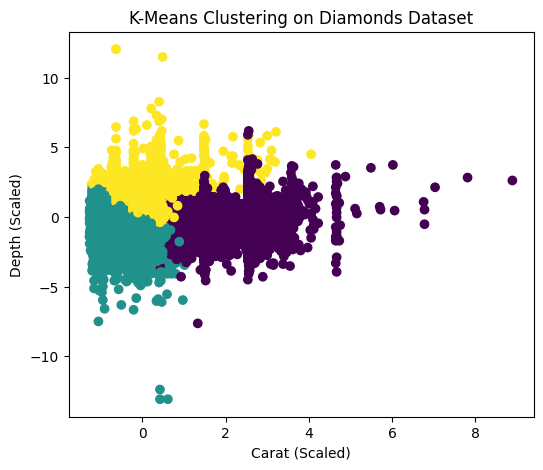

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(Y_scaled[:,0], Y_scaled[:,1], c=labels2, cmap='viridis')
plt.xlabel("Carat (Scaled)")
plt.ylabel("Depth (Scaled)")
plt.title("K-Means Clustering on Diamonds Dataset")
plt.show()

In [ ]:
!pip install minisom


  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.5-py3-none-any.whl size=12031 sha256=e75a007873d23419de0407de238a54152040d077e643946895bf1f6221189a08
  Stored in directory: /root/.cache/pip/wheels/0f/8c/a4/5b7aa56fa6ef11d536d45da775bcc5a2a1c163ff0f8f11990b
Successfully built minisom


In [ ]:
from minisom import MiniSom

som = MiniSom(x=10, y=10, input_len=Y_scaled.shape[1], sigma=1.0, learning_rate=0.5)
som.random_weights_init(Y_scaled)
som.train_random(Y_scaled, num_iteration=1000)

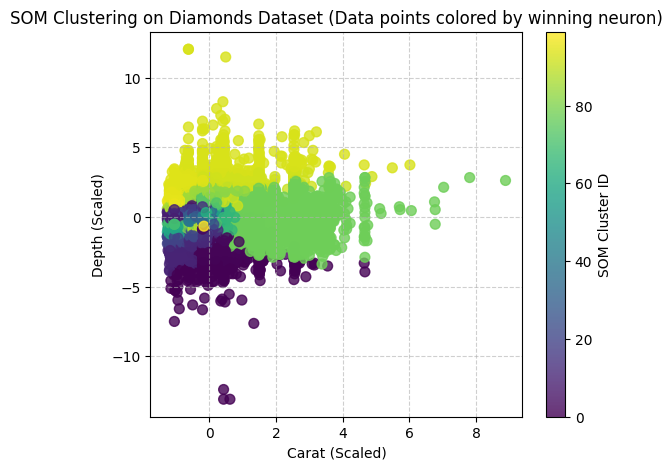

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

winning_neurons_coords = np.array([som.winner(x) for x in Y_scaled])

unique_winner_coords = np.unique(winning_neurons_coords, axis=0)
coord_to_label = {tuple(coord): i for i, coord in enumerate(unique_winner_coords)}

som_labels = np.array([coord_to_label[tuple(coord)] for coord in winning_neurons_coords])

plt.figure(figsize=(6,5))
plt.scatter(Y_scaled[:,0], Y_scaled[:,1], c=som_labels, cmap='viridis', s=50, alpha=0.8)
plt.xlabel("Carat (Scaled)")
plt.ylabel("Depth (Scaled)")
plt.title("SOM Clustering on Diamonds Dataset (Data points colored by winning neuron)")
plt.colorbar(label='SOM Cluster ID')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import math


In [ ]:
data = pd.read_csv("/content/WineQT.csv")
data.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [ ]:
alcohol = data["alcohol"].values
quality = data["quality"].values
n = len(alcohol)


In [ ]:
sum_alcohol = 0
for value in alcohol:
    sum_alcohol += value

mean_alcohol = sum_alcohol / n
print(mean_alcohol)


10.44211140274131


In [ ]:
variance_sum = 0
for value in alcohol:
    variance_sum += (value - mean_alcohol) ** 2

variance_alcohol = variance_sum / n
print(variance_alcohol)


1.1701227121933009


In [ ]:
std_alcohol = math.sqrt(variance_alcohol)
std_alcohol


1.0817221048833665

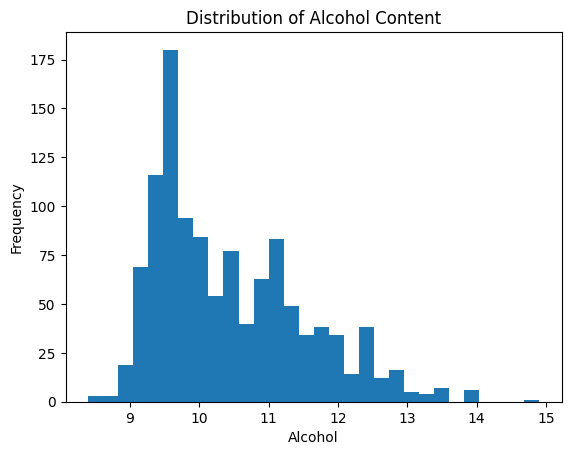

In [ ]:
plt.hist(alcohol, bins=30)
plt.title("Distribution of Alcohol Content")
plt.xlabel("Alcohol")
plt.ylabel("Frequency")
plt.show()


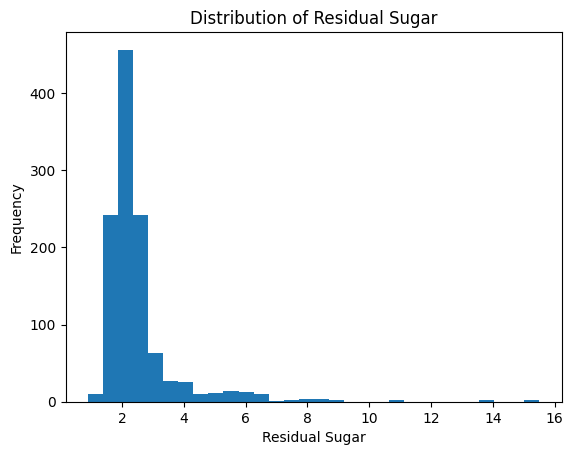

In [ ]:
residual_sugar = data["residual sugar"].values

plt.hist(residual_sugar, bins=30)
plt.title("Distribution of Residual Sugar")
plt.xlabel("Residual Sugar")
plt.ylabel("Frequency")
plt.show()


In [ ]:
sum_quality = 0
for q in quality:
    sum_quality += q

mean_quality = sum_quality / n


In [ ]:
numerator = 0
denom_x = 0
denom_y = 0

for i in range(n):
    numerator += (alcohol[i] - mean_alcohol) * (quality[i] - mean_quality)
    denom_x += (alcohol[i] - mean_alcohol) ** 2
    denom_y += (quality[i] - mean_quality) ** 2

correlation = numerator / math.sqrt(denom_x * denom_y)
print(correlation)


0.4848662118085124


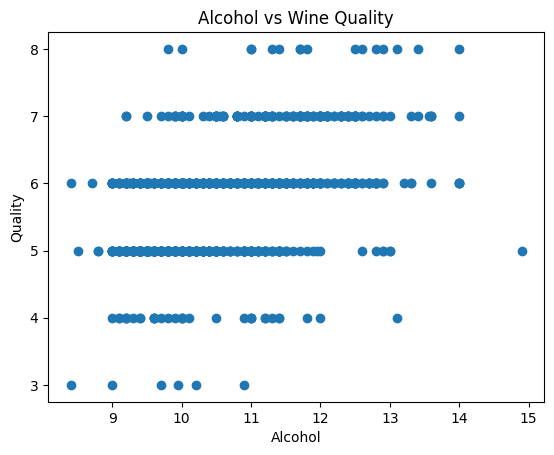

In [ ]:
plt.scatter(alcohol, quality)
plt.xlabel("Alcohol")
plt.ylabel("Quality")
plt.title("Alcohol vs Wine Quality")
plt.show()
